In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

visa_df=pd.read_csv(r"C:\Users\vaish\Documents\NareshIT\GEN_AI\Data_Files\Visadataset.csv")
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [4]:
num = visa_df.select_dtypes(exclude='str').columns
cat = visa_df.select_dtypes(include='str').columns

- we did only a categorical column
- we did only a numerical columns
- it is time to do multiple column
- lets assume continent vs casestatus
- we know different applicants from different continents
- in that some of visa are Cerified, some are Denied
- so visa certified and denied overall info available in case_status

In [5]:
visa_df['continent']

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: str

In [6]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [7]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [8]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Certified'
np.sum(con1&con2)

np.int64(11012)

In [9]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Denied'
np.sum(con1&con2)

np.int64(5849)

In [10]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Certified'
certi_count=np.sum(con1&con2)

con3=visa_df['case_status']=='Denied'
deni_count=np.sum(con1&con3)
certi_count,deni_count

(np.int64(11012), np.int64(5849))

In [11]:
keys = visa_df['continent'].value_counts().keys()
clist,dlist=[],[]
for i in keys:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    certi_count=np.sum(con1&con2)
    clist.append(certi_count)
    
    con3=visa_df['case_status']=='Denied'
    deni_count=np.sum(con1&con3)
    dlist.append(deni_count)
    
pd.DataFrame(zip(clist,dlist),columns=['Certified','Denied'],index=keys)

,Certified,Denied
continent,,
Asia,11012,5849
Europe,2957,775
North America,2037,1255
South America,493,359
Africa,397,154
Oceania,122,70


**Crosstab**

In [13]:
# which column i want to choose as index
# which column i want to choose as column 
col1=visa_df['case_status']
col2=visa_df['continent']
# pd.crosstab(index,columns)
pd.crosstab(col2,col1)


case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [14]:
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']

pd.crosstab(col1,[col1,col2])
pd.crosstab(col2,[col1,col3])
pd.crosstab(col3,[col2,col1])

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

<Axes: xlabel='continent'>

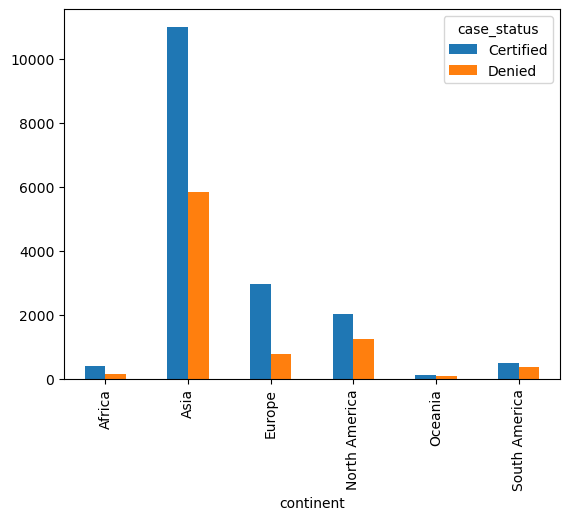

In [15]:
col1=visa_df['case_status']
col2=visa_df['continent']
r1=pd.crosstab(col2,col1)
r1.plot(kind='bar')

- categorical: **Frequency table bar chart pie cahrt**
- numerical: histogram
- categorical vs categorical: pd.crosstab
- numerical vs numcerical: scatterplot, covariance, correlation

**Scatter plots**

- it is a graph reprsentaion between two numerical columns
- it is also gives the relationship status between two columns
      - positive or negative or no relation

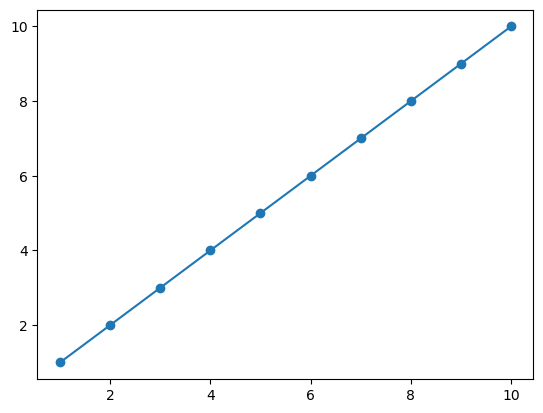

In [17]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

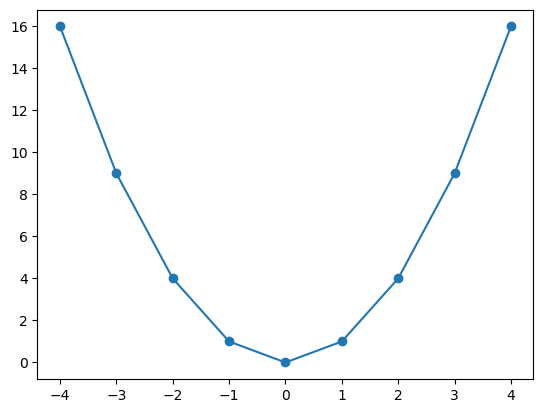

In [19]:
x=range(-4,5)
y=np.square(x)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

In [20]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='str')

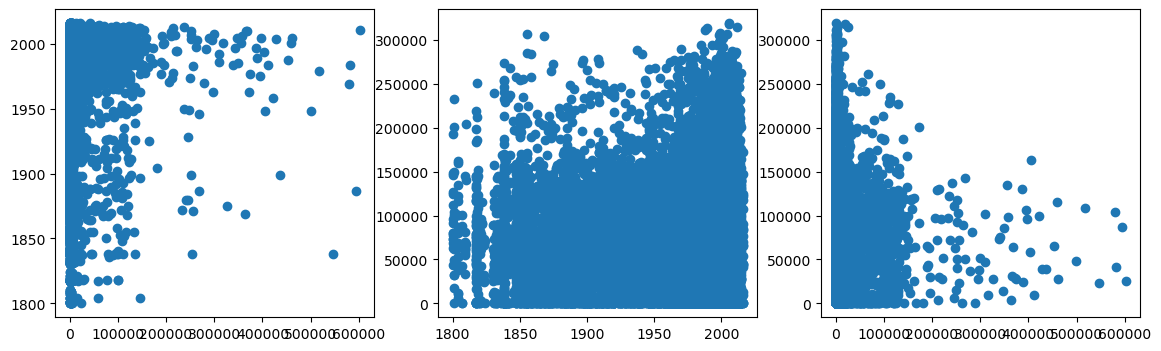

In [22]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(14,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)

**10 Aug 2026**

In [4]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [3]:
wine_df=pd.read_csv(r"C:\Users\vaish\Documents\NareshIT\GEN_AI\Data_Files\winequality_red.csv")
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


**Heatmap**

In [ ]:
- so far whatever the plots are
- 

<Axes: >

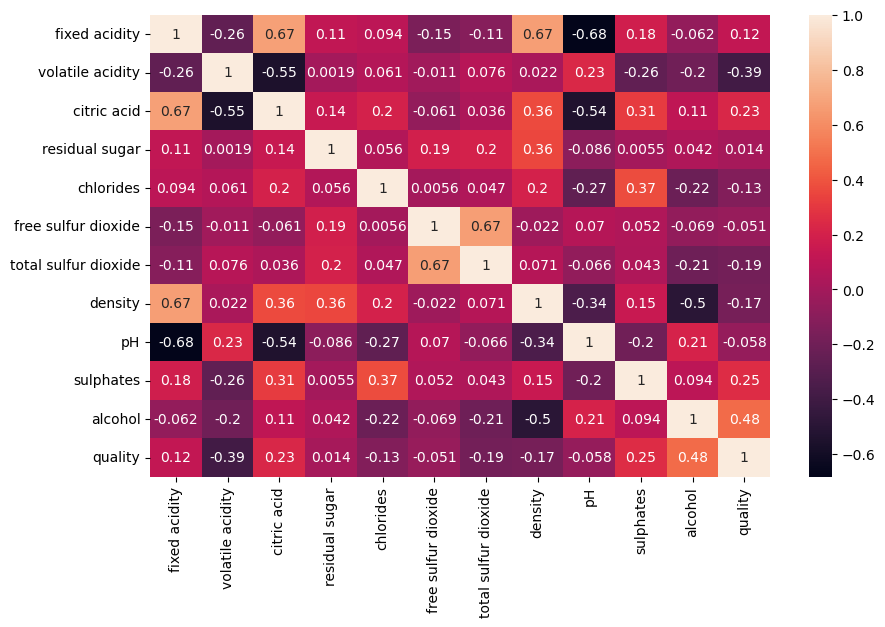

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(wine_df.corr(),
           annot=True)